In [4]:
import pandas as pd

df = pd.read_csv("pilot_merged.csv")

df.head()

,state,district,sub_centres,phcs,chcs,sub_divisional_hospital,district_hospital,year,lgd_matched_name,district_census2011_code,match_type,population
0,Karnataka,Bagalkote,233,55,8,5,1,2019-20,Bagalkote,556.0,exact,1889752.0
1,Karnataka,Bangalore Rural,199,50,2,4,0,2019-20,Bengaluru Rural,583.0,fuzzy,990923.0
2,Karnataka,Bangalore Urban,279,203,11,5,7,2019-20,Bengaluru Urban,572.0,fuzzy,9621551.0
3,Karnataka,Belgaum,620,153,16,9,0,2019-20,Belagavi,555.0,crosswalk,4779661.0
4,Karnataka,Bellary,293,74,11,6,1,2019-20,Ballari,565.0,crosswalk,2452595.0


In [5]:
df.shape

(629, 12)

In [6]:
df.isnull().sum()

state                        0
district                     0
sub_centres                  0
phcs                         0
chcs                         0
sub_divisional_hospital      0
district_hospital            0
year                         0
lgd_matched_name             1
district_census2011_code     1
match_type                   0
population                  28
dtype: int64

In [7]:
df[df["population"].isna()][
    ["state", "district", "year", "lgd_matched_name", "district_census2011_code", "match_type"]
]

,state,district,year,lgd_matched_name,district_census2011_code,match_type
36,Maharashtra,Brihan Mumbai,2019-20,NaN,NaN,none
52,Maharashtra,Palghar,2019-20,Palghar,0.0,exact
147,Uttar Pradesh,C S M Nagar,2019-20,Amethi,0.0,crosswalk
163,Uttar Pradesh,Hapur,2019-20,Hapur,0.0,exact
193,Uttar Pradesh,Sambhal,2019-20,Sambhal,0.0,exact
197,Uttar Pradesh,Shamli,2019-20,Shamli,0.0,exact
258,Maharashtra,Palghar,2020-21,Palghar,0.0,exact
305,Tamil Nadu,Chengalpattu,2020-21,Chengalpattu,0.0,exact
312,Tamil Nadu,Kallakurichi,2020-21,Kallakurichi,0.0,exact
318,Tamil Nadu,Mayiladuthurai,2020-21,Mayiladuthurai,0.0,exact


In [8]:
df["population"].describe()

count    6.010000e+02
mean     2.544908e+06
std      1.537582e+06
min      5.545190e+05
25%      1.578213e+06
50%      2.137045e+06
75%      3.307743e+06
max      1.106015e+07
Name: population, dtype: float64

In [9]:
df["population"].min()

np.float64(554519.0)

In [10]:
df_dhai = df[df["population"].notna()].copy()

In [11]:
df_dhai = df[df["population"].notna()].copy()

print("Original rows:", len(df))
print("Rows available for D-HAI:", len(df_dhai))

Original rows: 629
Rows available for D-HAI: 601


In [12]:
df_dhai["sub_centres_per_100k"] = (
    df_dhai["sub_centres"] / df_dhai["population"]
) * 100000

df_dhai["phcs_per_100k"] = (
    df_dhai["phcs"] / df_dhai["population"]
) * 100000

df_dhai["chcs_per_100k"] = (
    df_dhai["chcs"] / df_dhai["population"]
) * 100000

df_dhai["sub_divisional_hospital_per_100k"] = (
    df_dhai["sub_divisional_hospital"] / df_dhai["population"]
) * 100000

df_dhai["district_hospital_per_100k"] = (
    df_dhai["district_hospital"] / df_dhai["population"]
) * 100000

In [13]:
df_dhai[
    [
        "district",
        "population",
        "sub_centres_per_100k",
        "phcs_per_100k",
        "chcs_per_100k",
        "sub_divisional_hospital_per_100k",
        "district_hospital_per_100k"
    ]
].head(10)

,district,population,sub_centres_per_100k,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k
0,Bagalkote,1889752.0,12.329660,2.910435,0.423336,0.264585,0.052917
1,Bangalore Rural,990923.0,20.082287,5.045801,0.201832,0.403664,0.000000
2,Bangalore Urban,9621551.0,2.899740,2.109847,0.114327,0.051967,0.072753
3,Belgaum,4779661.0,12.971631,3.201064,0.334752,0.188298,0.000000
4,Bellary,2452595.0,11.946530,3.017212,0.448505,0.244639,0.040773
5,Bidar,1703300.0,16.145130,3.405155,0.469677,0.234838,0.000000
6,Bijapur,2177331.0,14.237615,3.077162,0.413350,0.183711,0.045928
7,Chamrajnagar,1020791.0,24.882665,6.073721,0.293890,0.293890,0.000000
8,Chikkaballapur,1255104.0,16.173958,4.860155,0.159349,0.398373,0.079675
9,Chikmagalur,1137961.0,32.338542,7.996759,0.439382,0.527259,0.087876


In [14]:
df_dhai[
    [
        "sub_centres_per_100k",
        "phcs_per_100k",
        "chcs_per_100k",
        "sub_divisional_hospital_per_100k",
        "district_hospital_per_100k"
    ]
].describe()

,sub_centres_per_100k,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k
count,601.000000,601.000000,601.000000,601.000000,601.000000
mean,14.181210,2.773291,0.529131,0.136879,0.061178
std,6.191240,1.295290,0.287933,0.203167,0.047578
min,0.000000,0.331467,0.000000,0.000000,0.000000
25%,10.201411,1.785217,0.337770,0.000000,0.028918
50%,12.329660,2.488865,0.465940,0.051045,0.057053
75%,17.775944,3.404576,0.654381,0.214586,0.086461
max,35.345948,7.996759,1.641990,2.123056,0.228321


In [15]:
facility_features = [
    "sub_centres_per_100k",
    "phcs_per_100k",
    "chcs_per_100k",
    "sub_divisional_hospital_per_100k",
    "district_hospital_per_100k"
]

for feature in facility_features:
    min_value = df_dhai[feature].min()
    max_value = df_dhai[feature].max()

    df_dhai[feature + "_norm"] = (
        (df_dhai[feature] - min_value)
        / (max_value - min_value)
    )

In [66]:
df_dhai[
    [
        "district",
        "sub_centres_per_100k_norm",
        "phcs_per_100k_norm",
        "chcs_per_100k_norm",
        "sub_divisional_hospital_per_100k_norm",
        "district_hospital_per_100k_norm"
    ]
].head(10)

,district,sub_centres_per_100k_norm,phcs_per_100k_norm,chcs_per_100k_norm,sub_divisional_hospital_per_100k_norm,district_hospital_per_100k_norm
0,Bagalkote,0.348828,0.336447,0.257819,0.124625,0.231765
1,Bangalore Rural,0.568164,0.615023,0.122919,0.190134,0.000000
2,Bangalore Urban,0.082039,0.232004,0.069627,0.024477,0.318644
3,Belgaum,0.366991,0.374362,0.203870,0.088692,0.000000
4,Bellary,0.337989,0.350377,0.273147,0.115230,0.178578
5,Bidar,0.456775,0.400988,0.286041,0.110613,0.000000
6,Bijapur,0.402808,0.358198,0.251737,0.086531,0.201154
7,Chamrajnagar,0.703975,0.749124,0.178984,0.138428,0.000000
8,Chikkaballapur,0.457590,0.590804,0.097047,0.187641,0.348958
9,Chikmagalur,0.914915,1.000000,0.267591,0.248349,0.384881


In [16]:
df_dhai["D_HAI_v1"] = (
    df_dhai["sub_centres_per_100k_norm"]
    + df_dhai["phcs_per_100k_norm"]
    + df_dhai["chcs_per_100k_norm"]
    + df_dhai["sub_divisional_hospital_per_100k_norm"]
    + df_dhai["district_hospital_per_100k_norm"]
) / 5

In [17]:
df_dhai[
    ["state", "district", "year", "D_HAI_v1"]
].head(10)

,state,district,year,D_HAI_v1
0,Karnataka,Bagalkote,2019-20,0.259897
1,Karnataka,Bangalore Rural,2019-20,0.299248
2,Karnataka,Bangalore Urban,2019-20,0.145358
3,Karnataka,Belgaum,2019-20,0.206783
4,Karnataka,Bellary,2019-20,0.251064
5,Karnataka,Bidar,2019-20,0.250883
6,Karnataka,Bijapur,2019-20,0.260086
7,Karnataka,Chamrajnagar,2019-20,0.354102
8,Karnataka,Chikkaballapur,2019-20,0.336408
9,Karnataka,Chikmagalur,2019-20,0.563147


In [18]:
df_dhai[
    df_dhai["district"].str.contains(
        "Mumbai|Pune",
        case=False,
        na=False
    )
][
    ["state", "district", "year", "population", "D_HAI_v1"]
].sort_values(["district", "year"])

,state,district,year,population,D_HAI_v1
251,Maharashtra,Mumbai,2020-21,3085411.0,0.022640
463,Maharashtra,Mumbai,2021-22,3085411.0,0.023486
252,Maharashtra,Mumbai Suburban,2020-21,9356962.0,0.018400
464,Maharashtra,Mumbai Suburban,2021-22,9356962.0,0.019236
54,Maharashtra,Pune,2019-20,9429408.0,0.143017
260,Maharashtra,Pune,2020-21,9429408.0,0.143137
472,Maharashtra,Pune,2021-22,9429408.0,0.144489


In [19]:
df_dhai[
    df_dhai["district"].str.contains(
        "Mumbai|Pune",
        case=False,
        na=False
    )
][
    [
        "state",
        "district",
        "year",
        "population",
        "sub_centres",
        "phcs",
        "chcs",
        "sub_divisional_hospital",
        "district_hospital",
        "D_HAI_v1"
    ]
].sort_values(["district", "year"])

,state,district,year,population,sub_centres,phcs,chcs,sub_divisional_hospital,district_hospital,D_HAI_v1
251,Maharashtra,Mumbai,2020-21,3085411.0,0,37,0,0,0,0.022640
463,Maharashtra,Mumbai,2021-22,3085411.0,0,38,0,0,0,0.023486
252,Maharashtra,Mumbai Suburban,2020-21,9356962.0,0,97,0,0,0,0.018400
464,Maharashtra,Mumbai Suburban,2021-22,9356962.0,0,100,0,0,0,0.019236
54,Maharashtra,Pune,2019-20,9429408.0,542,193,28,11,2,0.143017
260,Maharashtra,Pune,2020-21,9429408.0,545,192,40,5,1,0.143137
472,Maharashtra,Pune,2021-22,9429408.0,546,192,41,5,1,0.144489


In [20]:
df_dhai[df_dhai["district"] == "Mumbai"]

,state,district,sub_centres,phcs,chcs,sub_divisional_hospital,district_hospital,year,lgd_matched_name,district_census2011_code,...,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k,sub_centres_per_100k_norm,phcs_per_100k_norm,chcs_per_100k_norm,sub_divisional_hospital_per_100k_norm,district_hospital_per_100k_norm,D_HAI_v1
251,Maharashtra,Mumbai,0,37,0,0,0,2020-21,Mumbai,519.0,...,1.199192,0.0,0.0,0.0,0.0,0.113202,0.0,0.0,0.0,0.022640
463,Maharashtra,Mumbai,0,38,0,0,0,2021-22,Mumbai,519.0,...,1.231603,0.0,0.0,0.0,0.0,0.117430,0.0,0.0,0.0,0.023486


In [21]:
df_dhai[df_dhai["district"] == "Mumbai Suburban"]

,state,district,sub_centres,phcs,chcs,sub_divisional_hospital,district_hospital,year,lgd_matched_name,district_census2011_code,...,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k,sub_centres_per_100k_norm,phcs_per_100k_norm,chcs_per_100k_norm,sub_divisional_hospital_per_100k_norm,district_hospital_per_100k_norm,D_HAI_v1
252,Maharashtra,Mumbai Suburban,0,97,0,0,0,2020-21,Mumbai Suburban,518.0,...,1.036661,0.0,0.0,0.0,0.0,0.091998,0.0,0.0,0.0,0.018400
464,Maharashtra,Mumbai Suburban,0,100,0,0,0,2021-22,Mumbai Suburban,518.0,...,1.068723,0.0,0.0,0.0,0.0,0.096181,0.0,0.0,0.0,0.019236


In [22]:
df_dhai.duplicated(
    subset=["state", "district", "year"]
).sum()

np.int64(0)

In [23]:
# Check the minimum and maximum D-HAI values
# The D-HAI should be between 0 and 1 because we used min-max normalization.
print("Minimum D-HAI:", df_dhai["D_HAI_v1"].min())
print("Maximum D-HAI:", df_dhai["D_HAI_v1"].max())

Minimum D-HAI: 0.018399666714788508
Maximum D-HAI: 0.6782128675181894


In [24]:
# Check how many D-HAI values are missing
# A missing D-HAI would indicate a problem in the calculation.
print("Missing D-HAI values:", df_dhai["D_HAI_v1"].isna().sum())

Missing D-HAI values: 0


In [25]:
# Show summary statistics for the D-HAI scores
# This helps us understand how the accessibility index is distributed
# across the districts in our pilot dataset.
df_dhai["D_HAI_v1"].describe()

count    601.000000
mean       0.274887
std        0.103040
min        0.018400
25%        0.203409
50%        0.258707
75%        0.341176
max        0.678213
Name: D_HAI_v1, dtype: float64

In [26]:
# Check whether any D-HAI values are infinite
# Infinite values would indicate a numerical problem in the calculation.
print("Infinite D-HAI values:", df_dhai["D_HAI_v1"].isin([float("inf"), float("-inf")]).sum())

Infinite D-HAI values: 0


In [27]:
# Save the D-HAI v1 dataset as a CSV file
# This creates a separate output file and keeps the original pilot_merged.csv unchanged.
df_dhai.to_csv("dhai_v1_results.csv", index=False)

print("D-HAI v1 results saved successfully.")

D-HAI v1 results saved successfully.


## D-HAI v1 Methodology

D-HAI v1 is a baseline healthcare facility availability index constructed from the pilot district-year dataset.

The index uses five public healthcare facility indicators:

1. Sub-centres per 100,000 population
2. PHCs per 100,000 population
3. CHCs per 100,000 population
4. Sub-divisional hospitals per 100,000 population
5. District hospitals per 100,000 population

The facility counts are normalized using min-max normalization:

Normalized value = (x - minimum) / (maximum - minimum)

The five normalized indicators are given equal weight and averaged to obtain the D-HAI v1 score.

Higher D-HAI values indicate higher measured public-facility availability relative to population within the pilot dataset.

D-HAI v1 is used as an accessibility proxy and does not represent complete healthcare accessibility. The current pilot version does not include factors such as affordability, quality, travel time, or service utilization.

Rows without population data were excluded from the D-HAI calculation because population is required to construct the per-100,000 population indicators.

In [28]:
# Calculate three possible percentile-based thresholds
# These are only for comparison; we are not selecting one yet.

threshold_20 = df_dhai["D_HAI_v1"].quantile(0.20)
threshold_25 = df_dhai["D_HAI_v1"].quantile(0.25)
threshold_30 = df_dhai["D_HAI_v1"].quantile(0.30)

print("20th percentile threshold:", threshold_20)
print("25th percentile threshold:", threshold_25)
print("30th percentile threshold:", threshold_30)

20th percentile threshold: 0.19138161279923113
25th percentile threshold: 0.20340894250386649
30th percentile threshold: 0.21247016262125462


In [29]:
# Count how many district-year observations fall below each threshold
# This helps us compare the resulting class sizes before choosing a threshold.

for percentile, threshold in [
    ("20th percentile", threshold_20),
    ("25th percentile", threshold_25),
    ("30th percentile", threshold_30)
]:
    count = (df_dhai["D_HAI_v1"] <= threshold).sum()
    percentage = (count / len(df_dhai)) * 100

    print(
        percentile,
        "->",
        count,
        "observations (",
        round(percentage, 2),
        "%)"
    )

20th percentile -> 121 observations ( 20.13 %)
25th percentile -> 152 observations ( 25.29 %)
30th percentile -> 183 observations ( 30.45 %)


In [30]:
# Compare the number of low-D-HAI observations in each year
# for the three candidate percentile thresholds.

for percentile, threshold in [
    ("20th percentile", threshold_20),
    ("25th percentile", threshold_25),
    ("30th percentile", threshold_30)
]:
    print("\n", percentile, "threshold:", round(threshold, 4))

    # Count observations below or equal to the threshold for each year
    yearly_counts = (
        df_dhai[df_dhai["D_HAI_v1"] <= threshold]
        .groupby("year")
        .size()
    )

    print(yearly_counts)


 20th percentile threshold: 0.1914
year
2019-20    38
2020-21    41
2021-22    42
dtype: int64

 25th percentile threshold: 0.2034
year
2019-20    47
2020-21    51
2021-22    54
dtype: int64

 30th percentile threshold: 0.2125
year
2019-20    57
2020-21    64
2021-22    62
dtype: int64


In [31]:
# Define the fixed D-HAI threshold using the 25th percentile
# This threshold will be used to identify the lower-D-HAI group.

dhai_threshold = threshold_25

# Create the binary underserved label
# 1 = D-HAI at or below the threshold
# 0 = D-HAI above the threshold
df_dhai["underserved"] = (
    df_dhai["D_HAI_v1"] <= dhai_threshold
).astype(int)

print("D-HAI threshold:", dhai_threshold)
print("\nUnderserved class counts:")
print(df_dhai["underserved"].value_counts())

D-HAI threshold: 0.20340894250386649

Underserved class counts:
underserved
0    449
1    152
Name: count, dtype: int64


In [32]:
# Sort the data by district and year
# This ensures that the following year is correctly identified
# for each district.

df_dhai = df_dhai.sort_values(
    ["state", "district", "year"]
).reset_index(drop=True)

# Display the first few rows to verify the ordering
df_dhai[["state", "district", "year", "D_HAI_v1", "underserved"]].head(10)

,state,district,year,D_HAI_v1,underserved
0,Karnataka,Bagalkot,2020-21,0.213544,0
1,Karnataka,Bagalkote,2019-20,0.259897,0
2,Karnataka,Bagalkote,2021-22,0.259897,0
3,Karnataka,Ballari,2020-21,0.297137,0
4,Karnataka,Ballari,2021-22,0.296676,0
5,Karnataka,Bangalore Rural,2019-20,0.299248,0
6,Karnataka,Bangalore Urban,2019-20,0.145358,1
7,Karnataka,Belagavi,2020-21,0.225228,0
8,Karnataka,Belagavi,2021-22,0.202843,1
9,Karnataka,Belgaum,2019-20,0.206783,0


In [33]:
# Check the district codes for Bagalkot/Bagalkote and Belagavi/Belgaum
# These codes should help us identify whether the differently named rows
# actually refer to the same district.

df_dhai[
    df_dhai["district"].str.contains(
        "Bagalkot|Bagalkote|Belagavi|Belgaum",
        case=False,
        na=False
    )
][
    [
        "state",
        "district",
        "year",
        "district_census2011_code",
        "lgd_matched_name"
    ]
].sort_values(
    ["state", "district_census2011_code", "year"]
)

,state,district,year,district_census2011_code,lgd_matched_name
9,Karnataka,Belgaum,2019-20,555.0,Belagavi
7,Karnataka,Belagavi,2020-21,555.0,Belagavi
8,Karnataka,Belagavi,2021-22,555.0,Belagavi
1,Karnataka,Bagalkote,2019-20,556.0,Bagalkote
0,Karnataka,Bagalkot,2020-21,556.0,Bagalkote
2,Karnataka,Bagalkote,2021-22,556.0,Bagalkote


In [34]:
# Create a stable district identifier using the Census 2011 district code.
# This avoids problems caused by different district spellings across years.

df_dhai["district_id"] = df_dhai["district_census2011_code"]

# Check that the new identifier was created correctly
df_dhai[
    ["state", "district", "year", "district_id"]
].head(10)

,state,district,year,district_id
0,Karnataka,Bagalkot,2020-21,556.0
1,Karnataka,Bagalkote,2019-20,556.0
2,Karnataka,Bagalkote,2021-22,556.0
3,Karnataka,Ballari,2020-21,565.0
4,Karnataka,Ballari,2021-22,565.0
5,Karnataka,Bangalore Rural,2019-20,583.0
6,Karnataka,Bangalore Urban,2019-20,572.0
7,Karnataka,Belagavi,2020-21,555.0
8,Karnataka,Belagavi,2021-22,555.0
9,Karnataka,Belgaum,2019-20,555.0


In [35]:
# Sort the data by district ID and year
# This ensures that each district's years are in the correct order.
df_dhai = df_dhai.sort_values(
    ["district_id", "year"]
).reset_index(drop=True)

# Create the next-year underserved target for each district.
# The shift(-1) takes the underserved label from the following row/year.
df_dhai["underserved_next_year"] = (
    df_dhai.groupby("district_id")["underserved"].shift(-1)
)

# Show a few rows to verify the new target
df_dhai[
    [
        "state",
        "district",
        "year",
        "underserved",
        "underserved_next_year"
    ]
].head(15)

,state,district,year,underserved,underserved_next_year
0,Rajasthan,Ganganagar,2019-20,0,0.0
1,Rajasthan,Ganganagar,2020-21,0,0.0
2,Rajasthan,Ganganagar,2021-22,0,NaN
3,Rajasthan,Hanumangarh,2019-20,0,0.0
4,Rajasthan,Hanumangarh,2020-21,0,0.0
5,Rajasthan,Hanumangarh,2021-22,0,NaN
6,Rajasthan,Bikaner,2019-20,0,0.0
7,Rajasthan,Bikaner,2020-21,0,0.0
8,Rajasthan,Bikaner,2021-22,0,NaN
9,Rajasthan,Churu,2019-20,0,0.0


In [36]:
# Check that the next-year target also works when district names change.
# We use the stable district ID, so the name change should not cause a problem.

df_dhai[
    df_dhai["district_id"].isin([555, 556])
][
    [
        "state",
        "district",
        "year",
        "D_HAI_v1",
        "underserved",
        "underserved_next_year"
    ]
]

,state,district,year,D_HAI_v1,underserved,underserved_next_year
415,Karnataka,Belgaum,2019-20,0.206783,0,0.0
416,Karnataka,Belagavi,2020-21,0.225228,0,1.0
417,Karnataka,Belagavi,2021-22,0.202843,1,NaN
418,Karnataka,Bagalkote,2019-20,0.259897,0,0.0
419,Karnataka,Bagalkot,2020-21,0.213544,0,0.0
420,Karnataka,Bagalkote,2021-22,0.259897,0,NaN


In [37]:
# Count rows that have a valid next-year target
# The final year of each district has no following year,
# so those rows will have a missing target.

print(
    "Rows with next-year target:",
    df_dhai["underserved_next_year"].notna().sum()
)

print(
    "Rows without next-year target:",
    df_dhai["underserved_next_year"].isna().sum()
)

Rows with next-year target: 400
Rows without next-year target: 201


In [38]:
# Keep only rows that have a valid next-year target
# These are the observations we can use for the t -> t+1 prediction task.
df_ml = df_dhai[
    df_dhai["underserved_next_year"].notna()
].copy()

# Convert the target to integer values
# 0 = not underserved in the following year
# 1 = underserved in the following year
df_ml["underserved_next_year"] = (
    df_ml["underserved_next_year"].astype(int)
)

# Display the number and percentage of each target class
print("Total ML observations:", len(df_ml))
print("\nNext-year target counts:")
print(df_ml["underserved_next_year"].value_counts())

print("\nNext-year target percentages:")
print(
    (df_ml["underserved_next_year"].value_counts(normalize=True) * 100)
    .round(2)
)

Total ML observations: 400

Next-year target counts:
underserved_next_year
0    297
1    103
Name: count, dtype: int64

Next-year target percentages:
underserved_next_year
0    74.25
1    25.75
Name: proportion, dtype: float64


In [39]:
# Check how many district-year observations have a consecutive following year.
# We want the target to represent exactly t -> t+1, not a jump over a missing year.

year_order = {
    "2019-20": 2019,
    "2020-21": 2020,
    "2021-22": 2021
}

# Convert the year labels into their starting year
df_ml["year_num"] = df_ml["year"].map(year_order)

# Get the following year's starting year for each district
df_ml["next_year_num"] = (
    df_ml.groupby("district_id")["year_num"].shift(-1)
)

# Check whether the following row is exactly one year later
df_ml["is_consecutive"] = (
    df_ml["next_year_num"] == df_ml["year_num"] + 1
)

print("Consecutive t -> t+1 rows:", df_ml["is_consecutive"].sum())
print("Non-consecutive rows:", (~df_ml["is_consecutive"]).sum())

Consecutive t -> t+1 rows: 199
Non-consecutive rows: 201


In [40]:
# Convert the year labels into numerical starting years
# This allows us to check whether the next available year is exactly one year later.

year_order = {
    "2019-20": 2019,
    "2020-21": 2020,
    "2021-22": 2021
}

df_dhai["year_num"] = df_dhai["year"].map(year_order)

# Find the next available year for each district
# We use the stable district_id so name changes do not affect matching.
df_dhai["next_available_year"] = (
    df_dhai.groupby("district_id")["year_num"].shift(-1)
)

# Check whether the next available year is exactly one year later.
df_dhai["is_consecutive"] = (
    df_dhai["next_available_year"] == df_dhai["year_num"] + 1
)

# Look only at rows that have a next-year target
# because the final year naturally has no following year.
target_rows = df_dhai[
    df_dhai["underserved_next_year"].notna()
]

print(
    "Rows with a valid next-year target:",
    len(target_rows)
)

print(
    "Valid consecutive t -> t+1 rows:",
    target_rows["is_consecutive"].sum()
)

print(
    "Non-consecutive rows:",
    (~target_rows["is_consecutive"]).sum()
)

Rows with a valid next-year target: 400
Valid consecutive t -> t+1 rows: 400
Non-consecutive rows: 0


In [41]:
# Count how many observations belong to each prediction transition.
# This shows how much data we have for training and final temporal testing.

print(
    df_ml.groupby("year").size()
)

year
2019-20    199
2020-21    201
dtype: int64


In [42]:
# Create the training set using the earliest transition.
# The model will learn from 2019-20 information to predict 2020-21.
train_df = df_ml[
    df_ml["year"] == "2019-20"
].copy()

# Create the test set using the later transition.
# The model will use 2020-21 information to predict 2021-22.
test_df = df_ml[
    df_ml["year"] == "2020-21"
].copy()

# Display the sizes of both datasets
print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

Training observations: 199
Testing observations: 201


In [43]:
# List the facility availability features that can be used as predictors.
# These features describe the district at the current time t.

feature_columns = [
    "sub_centres_per_100k",
    "phcs_per_100k",
    "chcs_per_100k",
    "sub_divisional_hospital_per_100k",
    "district_hospital_per_100k",
    "population"
]

# Display the summary statistics of the candidate features
# using only the training data.
train_df[feature_columns].describe()

,sub_centres_per_100k,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k,population
count,199.000000,199.000000,199.000000,199.000000,199.000000,1.990000e+02
mean,14.398787,2.813471,0.516388,0.144135,0.066609,2.520277e+06
std,6.033186,1.296055,0.272153,0.232169,0.046059,1.493386e+06
min,0.000000,0.331467,0.000000,0.000000,0.000000,5.545190e+05
25%,10.329396,1.844329,0.325755,0.000000,0.038390,1.571460e+06
50%,12.398479,2.515819,0.463991,0.055130,0.059501,2.089649e+06
75%,17.833092,3.429295,0.647867,0.215213,0.092186,3.284221e+06
max,35.345948,7.996759,1.489311,2.123056,0.228321,1.106015e+07


In [44]:
# Check for missing values in the selected ML features.
# We check both training and testing data before building the models.

print("Missing values in training data:")
print(train_df[feature_columns].isna().sum())

print("\nMissing values in testing data:")
print(test_df[feature_columns].isna().sum())

Missing values in training data:
sub_centres_per_100k                0
phcs_per_100k                       0
chcs_per_100k                       0
sub_divisional_hospital_per_100k    0
district_hospital_per_100k          0
population                          0
dtype: int64

Missing values in testing data:
sub_centres_per_100k                0
phcs_per_100k                       0
chcs_per_100k                       0
sub_divisional_hospital_per_100k    0
district_hospital_per_100k          0
population                          0
dtype: int64


In [45]:
# Create the input features for the training set.
# X contains only information available at the current year t.
X_train = train_df[feature_columns].copy()

# Create the input features for the testing set.
X_test = test_df[feature_columns].copy()

# Create the training target.
# y_train represents whether the district becomes underserved in year t+1.
y_train = train_df["underserved_next_year"].copy()

# Create the testing target.
# y_test represents the actual underserved status in the following year.
y_test = test_df["underserved_next_year"].copy()

# Check the dimensions of the four datasets.
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (199, 6)
X_test shape: (201, 6)
y_train shape: (199,)
y_test shape: (201,)


In [46]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Create a pipeline that first standardizes the features
# and then trains a Logistic Regression classifier.
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model using only the training data.
logistic_model.fit(X_train, y_train)

# Predict the class for the unseen test data.
y_pred_logistic = logistic_model.predict(X_test)

# Get predicted probabilities for the positive class.
# These probabilities are required for ROC-AUC and PR-AUC.
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate classification metrics.
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))
print("PR-AUC:", average_precision_score(y_test, y_prob_logistic))

# Display the confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.945273631840796
Precision: 0.9215686274509803
Recall: 0.8703703703703703
F1 Score: 0.8952380952380953
ROC-AUC: 0.982363315696649
PR-AUC: 0.9533804363758355

Confusion Matrix:
[[143   4]
 [  7  47]]


In [47]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Create a pipeline that first standardizes the features
# and then trains a Logistic Regression classifier.
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])

# Train the model using only the training data.
logistic_model.fit(X_train, y_train)

# Predict the class for the unseen test data.
y_pred_logistic = logistic_model.predict(X_test)

# Get predicted probabilities for the positive class.
# These probabilities are required for ROC-AUC and PR-AUC.
y_prob_logistic = logistic_model.predict_proba(X_test)[:, 1]

# Calculate classification metrics.
print("Accuracy:", accuracy_score(y_test, y_pred_logistic))
print("Precision:", precision_score(y_test, y_pred_logistic))
print("Recall:", recall_score(y_test, y_pred_logistic))
print("F1 Score:", f1_score(y_test, y_pred_logistic))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_logistic))
print("PR-AUC:", average_precision_score(y_test, y_prob_logistic))

# Display the confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_logistic))

Accuracy: 0.945273631840796
Precision: 0.9215686274509803
Recall: 0.8703703703703703
F1 Score: 0.8952380952380953
ROC-AUC: 0.982363315696649
PR-AUC: 0.9533804363758355

Confusion Matrix:
[[143   4]
 [  7  47]]


In [48]:
from sklearn.tree import DecisionTreeClassifier

# Create a Decision Tree classifier.
# The tree can learn non-linear relationships between the features
# and the next-year underserved target.
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

# Train the Decision Tree using only the training data.
decision_tree.fit(X_train, y_train)

# Predict the classes for the test data.
y_pred_tree = decision_tree.predict(X_test)

# Get probabilities for the positive class.
# These probabilities are needed for ROC-AUC and PR-AUC.
y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

# Calculate classification metrics.
print("Accuracy:", accuracy_score(y_test, y_pred_tree))
print("Precision:", precision_score(y_test, y_pred_tree))
print("Recall:", recall_score(y_test, y_pred_tree))
print("F1 Score:", f1_score(y_test, y_pred_tree))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tree))
print("PR-AUC:", average_precision_score(y_test, y_prob_tree))

# Display the confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tree))

Accuracy: 0.9203980099502488
Precision: 0.8518518518518519
Recall: 0.8518518518518519
F1 Score: 0.8518518518518519
ROC-AUC: 0.9665532879818594
PR-AUC: 0.9017735330056307

Confusion Matrix:
[[139   8]
 [  8  46]]


In [49]:
from sklearn.ensemble import RandomForestClassifier

# Create a Random Forest classifier.
# It combines multiple decision trees to model non-linear relationships.
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the Random Forest using only the training data.
random_forest.fit(X_train, y_train)

# Predict the classes for the test data.
y_pred_rf = random_forest.predict(X_test)

# Get probabilities for the positive class.
# These probabilities are needed for ROC-AUC and PR-AUC.
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

# Calculate classification metrics.
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_rf))

# Display the confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Accuracy: 0.9701492537313433
Precision: 0.9615384615384616
Recall: 0.9259259259259259
F1 Score: 0.9433962264150944
ROC-AUC: 0.9935122197026959
PR-AUC: 0.9816982027076943

Confusion Matrix:
[[145   2]
 [  4  50]]


In [50]:
# Get the importance of each input feature from the trained Random Forest.
# Higher values indicate that the feature was used more heavily
# by the trees when making predictions.

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest.feature_importances_
})

# Sort the features from highest to lowest importance.
feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

# Display the feature importance table.
feature_importance

,feature,importance
0,population,0.266243
1,sub_centres_per_100k,0.251754
2,district_hospital_per_100k,0.216822
3,phcs_per_100k,0.125760
4,chcs_per_100k,0.086105
5,sub_divisional_hospital_per_100k,0.053316


In [51]:
from sklearn.model_selection import GridSearchCV

# Define the hyperparameters we want to test.
# Different combinations will be evaluated using only the training data.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# Create a new Random Forest model for tuning.
rf_tuning = RandomForestClassifier(
    random_state=42
)

# Set up grid search with 5-fold cross-validation.
# F1 is used because our target classes are not perfectly balanced.
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Perform hyperparameter tuning using training data only.
grid_search.fit(X_train, y_train)

# Display the best hyperparameter combination.
print("Best parameters:")
print(grid_search.best_params_)

# Display the best cross-validation F1 score.
print("\nBest cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best cross-validation F1 score:
0.7559406537734711


In [52]:
# Get the best Random Forest model found by GridSearchCV.
# This model was selected using only the training data.
best_rf = grid_search.best_estimator_

# Predict the classes for the untouched test data.
y_pred_tuned_rf = best_rf.predict(X_test)

# Get probabilities for the positive class.
# These are required for ROC-AUC and PR-AUC.
y_prob_tuned_rf = best_rf.predict_proba(X_test)[:, 1]

# Calculate the final test-set metrics.
print("Accuracy:", accuracy_score(y_test, y_pred_tuned_rf))
print("Precision:", precision_score(y_test, y_pred_tuned_rf))
print("Recall:", recall_score(y_test, y_pred_tuned_rf))
print("F1 Score:", f1_score(y_test, y_pred_tuned_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_tuned_rf))
print("PR-AUC:", average_precision_score(y_test, y_prob_tuned_rf))

# Display the confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned_rf))

Accuracy: 0.9701492537313433
Precision: 0.9615384615384616
Recall: 0.9259259259259259
F1 Score: 0.9433962264150944
ROC-AUC: 0.9935122197026959
PR-AUC: 0.9816982027076943

Confusion Matrix:
[[145   2]
 [  4  50]]


In [53]:
# Create a comparison table for the three baseline models.
# This allows us to compare their performance using the same test set.

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_logistic),
        accuracy_score(y_test, y_pred_tree),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_logistic),
        precision_score(y_test, y_pred_tree),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_logistic),
        recall_score(y_test, y_pred_tree),
        recall_score(y_test, y_pred_rf)
    ],
    "F1": [
        f1_score(y_test, y_pred_logistic),
        f1_score(y_test, y_pred_tree),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_logistic),
        roc_auc_score(y_test, y_prob_tree),
        roc_auc_score(y_test, y_prob_rf)
    ],
    "PR-AUC": [
        average_precision_score(y_test, y_prob_logistic),
        average_precision_score(y_test, y_prob_tree),
        average_precision_score(y_test, y_prob_rf)
    ]
})

# Round the metrics for easier reading.
model_results.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.9453,0.9216,0.8704,0.8952,0.9824,0.9534
1,Decision Tree,0.9204,0.8519,0.8519,0.8519,0.9666,0.9018
2,Random Forest,0.9701,0.9615,0.9259,0.9434,0.9935,0.9817


In [54]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the untouched test set.
# Each feature is shuffled one at a time to see how much the model performance changes.
permutation_result = permutation_importance(
    best_rf,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

# Create a table containing the permutation importance results.
permutation_importance_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": permutation_result.importances_mean,
    "importance_std": permutation_result.importances_std
})

# Sort features by their average importance.
permutation_importance_df = permutation_importance_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# Display the results.
permutation_importance_df

,feature,importance_mean,importance_std
0,sub_centres_per_100k,0.361207,0.052157
1,district_hospital_per_100k,0.267020,0.039847
2,phcs_per_100k,0.056319,0.013663
3,population,0.030820,0.016882
4,chcs_per_100k,0.019026,0.016341
5,sub_divisional_hospital_per_100k,-0.002746,0.006327


In [106]:
# Install the SHAP library in the current Jupyter environment.
%pip install shap

Defaulting to user installation because normal site-packages is not writeable

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   --------------------------------------

In [55]:
# Import SHAP after installation.
import shap

# Display the installed SHAP version.
print("SHAP version:", shap.__version__)

SHAP version: 0.52.0


In [56]:
# Import the required libraries for Random Forest tuning.
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Define the Random Forest hyperparameter combinations to test.
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# Create the Random Forest model.
rf_tuning = RandomForestClassifier(random_state=42)

# Set up 5-fold cross-validation using F1 score.
grid_search = GridSearchCV(
    rf_tuning,
    param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train and tune the Random Forest using the training data only.
grid_search.fit(X_train, y_train)

# Store the best Random Forest model.
best_rf = grid_search.best_estimator_

# Display the best parameters found during tuning.
print("Best parameters:", grid_search.best_params_)

# Display the best cross-validation F1 score.
print("Best CV F1:", grid_search.best_score_)

Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1: 0.7559406537734711


In [57]:
# Create a SHAP TreeExplainer for the tuned Random Forest.
explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values for the test dataset.
shap_values = explainer.shap_values(X_test)

# Display the SHAP values shape.
print("SHAP values shape:", getattr(shap_values, "shape", "No shape attribute"))

SHAP values shape: (201, 6, 2)


In [58]:
# Select SHAP values for class 1 (underserved next year).
# The last dimension contains the two classes: 0 and 1.
shap_values_class1 = shap_values[:, :, 1]

# Display the resulting shape.
print("Class 1 SHAP values shape:", shap_values_class1.shape)

Class 1 SHAP values shape: (201, 6)


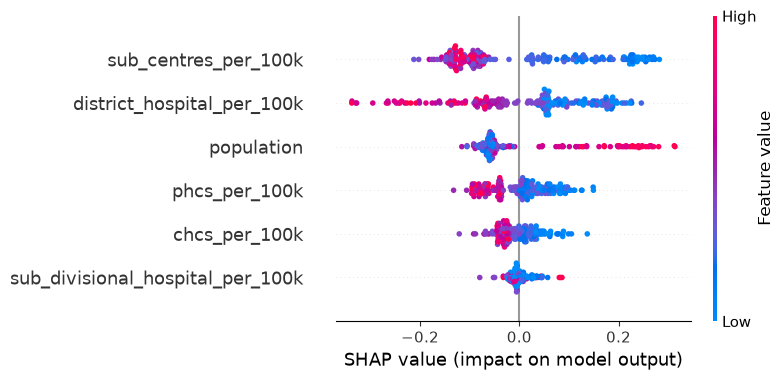

In [59]:
# Create the SHAP summary plot for the underserved class (class 1).
# Each point represents one district-year observation.
# The horizontal position shows whether the feature pushes the prediction
# toward or away from the underserved class.

shap.summary_plot(
    shap_values_class1,
    X_test,
    feature_names=feature_columns
)

In [60]:
# Create a separate copy so the original D-HAI v1 remains unchanged.
df_temporal = df_dhai.copy()

# List the five facility-density features used in the D-HAI.
facility_features = [
    "sub_centres_per_100k",
    "phcs_per_100k",
    "chcs_per_100k",
    "sub_divisional_hospital_per_100k",
    "district_hospital_per_100k"
]

# Use only the earliest year as the baseline for normalization.
# This prevents information from later years entering the index definition.
baseline_df = df_temporal[df_temporal["year"] == "2019-20"].copy()

# Store the baseline minimum and maximum for every facility feature.
baseline_min = {}
baseline_max = {}

for feature in facility_features:
    baseline_min[feature] = baseline_df[feature].min()
    baseline_max[feature] = baseline_df[feature].max()

# Apply the fixed baseline normalization to all years.
for feature in facility_features:
    df_temporal[feature + "_norm"] = (
        (df_temporal[feature] - baseline_min[feature])
        / (baseline_max[feature] - baseline_min[feature])
    )

# Calculate the temporally consistent D-HAI.
df_temporal["D_HAI_temporal"] = (
    df_temporal["sub_centres_per_100k_norm"]
    + df_temporal["phcs_per_100k_norm"]
    + df_temporal["chcs_per_100k_norm"]
    + df_temporal["sub_divisional_hospital_per_100k_norm"]
    + df_temporal["district_hospital_per_100k_norm"]
) / 5

# Define the underserved threshold using only the baseline year.
temporal_threshold = df_temporal.loc[
    df_temporal["year"] == "2019-20",
    "D_HAI_temporal"
].quantile(0.25)

# Display the threshold.
print("Temporal D-HAI threshold:", temporal_threshold)

# Check the resulting D-HAI range.
print("D-HAI temporal minimum:", df_temporal["D_HAI_temporal"].min())
print("D-HAI temporal maximum:", df_temporal["D_HAI_temporal"].max())

Temporal D-HAI threshold: 0.2115131448009746
D-HAI temporal minimum: 0.018399666714788508
D-HAI temporal maximum: 0.693975653693014


In [61]:
# Create the underserved label using the fixed baseline threshold.
# The same threshold is applied to every year.
df_temporal["underserved"] = (
    df_temporal["D_HAI_temporal"] <= temporal_threshold
).astype(int)

# Sort districts chronologically before creating the next-year target.
df_temporal = df_temporal.sort_values(
    ["district_id", "year_num"]
).reset_index(drop=True)

# Create the next-year underserved target.
# For each district, the current year's features will predict
# whether that district is underserved in the following year.
df_temporal["underserved_next_year"] = (
    df_temporal.groupby("district_id")["underserved"].shift(-1)
)

# Keep only rows for which a valid next-year target exists.
df_ml_temporal = df_temporal[
    df_temporal["underserved_next_year"].notna()
].copy()

# Convert the target from float to integer.
df_ml_temporal["underserved_next_year"] = (
    df_ml_temporal["underserved_next_year"].astype(int)
)

# Display the number of usable prediction rows.
print("Total ML rows:", len(df_ml_temporal))

# Display the target class distribution.
print("\nTarget distribution:")
print(df_ml_temporal["underserved_next_year"].value_counts())

# Display the target percentages.
print("\nTarget percentages:")
print(
    df_ml_temporal["underserved_next_year"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

Total ML rows: 400

Target distribution:
underserved_next_year
0    291
1    109
Name: count, dtype: int64

Target percentages:
underserved_next_year
0    72.75
1    27.25
Name: proportion, dtype: float64


In [62]:
# Convert the year labels into numeric values for checking.
year_order = {
    "2019-20": 2019,
    "2020-21": 2020,
    "2021-22": 2021
}

# Add a numeric year column.
df_temporal["year_num"] = df_temporal["year"].map(year_order)

# Get the next available year for each district.
df_temporal["next_available_year"] = (
    df_temporal.groupby("district_id")["year_num"].shift(-1)
)

# Check whether the next observation is exactly one year later.
df_temporal["is_consecutive"] = (
    df_temporal["next_available_year"]
    == df_temporal["year_num"] + 1
)

# Check only rows that have a valid next-year target.
target_rows = df_temporal[
    df_temporal["underserved_next_year"].notna()
]

# Count consecutive and non-consecutive prediction rows.
consecutive_count = target_rows["is_consecutive"].sum()
non_consecutive_count = (~target_rows["is_consecutive"]).sum()

print("Valid t → t+1 rows:", len(target_rows))
print("Consecutive t → t+1 rows:", consecutive_count)
print("Non-consecutive rows:", non_consecutive_count)

Valid t → t+1 rows: 400
Consecutive t → t+1 rows: 400
Non-consecutive rows: 0


In [63]:
# Define the six features used by the machine-learning models.
# These are measured at year t and are used to predict the following year.
feature_columns = [
    "sub_centres_per_100k",
    "phcs_per_100k",
    "chcs_per_100k",
    "sub_divisional_hospital_per_100k",
    "district_hospital_per_100k",
    "population"
]

# Create the final modeling dataset from rows with a valid next-year target.
df_ml_final = df_temporal[
    df_temporal["underserved_next_year"].notna()
].copy()

# Use 2019-20 observations to predict 2020-21 outcomes.
train_df_final = df_ml_final[
    df_ml_final["year"] == "2019-20"
].copy()

# Use 2020-21 observations to predict 2021-22 outcomes.
test_df_final = df_ml_final[
    df_ml_final["year"] == "2020-21"
].copy()

# Create the training feature matrix.
X_train_final = train_df_final[feature_columns].copy()

# Create the test feature matrix.
X_test_final = test_df_final[feature_columns].copy()

# Create the training target.
y_train_final = train_df_final["underserved_next_year"].copy()

# Create the test target.
y_test_final = test_df_final["underserved_next_year"].copy()

# Display the dataset sizes.
print("Training features:", X_train_final.shape)
print("Test features:", X_test_final.shape)
print("Training target:", y_train_final.shape)
print("Test target:", y_test_final.shape)

# Check for missing values in the model features.
print("\nMissing values in training features:")
print(X_train_final.isna().sum())

print("\nMissing values in test features:")
print(X_test_final.isna().sum())

Training features: (199, 6)
Test features: (201, 6)
Training target: (199,)
Test target: (201,)

Missing values in training features:
sub_centres_per_100k                0
phcs_per_100k                       0
chcs_per_100k                       0
sub_divisional_hospital_per_100k    0
district_hospital_per_100k          0
population                          0
dtype: int64

Missing values in test features:
sub_centres_per_100k                0
phcs_per_100k                       0
chcs_per_100k                       0
sub_divisional_hospital_per_100k    0
district_hospital_per_100k          0
population                          0
dtype: int64


In [64]:
# Import the required machine-learning models and preprocessing tools.
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Create the Logistic Regression pipeline.
# StandardScaler is fitted only on the training data through the pipeline.
logistic_final = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        random_state=42,
        max_iter=1000
    ))
])

# Train Logistic Regression on the training data.
logistic_final.fit(X_train_final, y_train_final)

# Create the Decision Tree model.
decision_tree_final = DecisionTreeClassifier(
    random_state=42,
    max_depth=4
)

# Train the Decision Tree.
decision_tree_final.fit(X_train_final, y_train_final)

# Create the Random Forest model.
random_forest_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the Random Forest.
random_forest_final.fit(X_train_final, y_train_final)

# Confirm that all three models have been trained.
print("All three final models trained successfully.")

All three final models trained successfully.


In [65]:
# Import the evaluation metrics.
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Generate predictions from Logistic Regression.
logistic_pred = logistic_final.predict(X_test_final)
logistic_prob = logistic_final.predict_proba(X_test_final)[:, 1]

# Generate predictions from the Decision Tree.
tree_pred = decision_tree_final.predict(X_test_final)
tree_prob = decision_tree_final.predict_proba(X_test_final)[:, 1]

# Generate predictions from the Random Forest.
rf_pred = random_forest_final.predict(X_test_final)
rf_prob = random_forest_final.predict_proba(X_test_final)[:, 1]

# Calculate all required classification metrics.
def calculate_metrics(y_true, y_pred, y_prob):
    # Return the requested evaluation metrics.
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }

# Calculate metrics for all three models.
final_results = {
    "Logistic Regression": calculate_metrics(
        y_test_final, logistic_pred, logistic_prob
    ),
    "Decision Tree": calculate_metrics(
        y_test_final, tree_pred, tree_prob
    ),
    "Random Forest": calculate_metrics(
        y_test_final, rf_pred, rf_prob
    )
}

# Convert the results into a readable table.
final_results_df = pd.DataFrame(final_results).T

# Round the values for easier presentation.
final_results_df = final_results_df.round(4)

# Display the final model comparison.
final_results_df

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.9403,0.8929,0.8929,0.8929,0.9814,0.9577
Decision Tree,0.9005,0.8333,0.8036,0.8182,0.9622,0.9033
Random Forest,0.9751,0.9636,0.9464,0.9550,0.9932,0.9846


In [66]:
# Calculate confusion matrices for all three final models.
logistic_cm = confusion_matrix(y_test_final, logistic_pred)
tree_cm = confusion_matrix(y_test_final, tree_pred)
rf_cm = confusion_matrix(y_test_final, rf_pred)

# Display the Logistic Regression confusion matrix.
print("Logistic Regression:")
print(logistic_cm)

# Display the Decision Tree confusion matrix.
print("\nDecision Tree:")
print(tree_cm)

# Display the Random Forest confusion matrix.
print("\nRandom Forest:")
print(rf_cm)

Logistic Regression:
[[139   6]
 [  6  50]]

Decision Tree:
[[136   9]
 [ 11  45]]

Random Forest:
[[143   2]
 [  3  53]]


In [67]:
# Import GridSearchCV for hyperparameter optimization.
from sklearn.model_selection import GridSearchCV

# Define the Random Forest hyperparameters to test.
param_grid_final = {
    "n_estimators": [100, 200],
    "max_depth": [None, 5, 10],
    "min_samples_split": [2, 5]
}

# Create a base Random Forest model.
rf_tuning_final = RandomForestClassifier(
    random_state=42
)

# Set up 5-fold cross-validation using F1 score.
grid_search_final = GridSearchCV(
    estimator=rf_tuning_final,
    param_grid=param_grid_final,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Perform hyperparameter tuning using training data only.
grid_search_final.fit(
    X_train_final,
    y_train_final
)

# Store the best tuned Random Forest.
best_rf_final = grid_search_final.best_estimator_

# Display the best hyperparameters.
print("Best parameters:", grid_search_final.best_params_)

# Display the best cross-validation F1 score.
print("Best CV F1:", grid_search_final.best_score_)

Best parameters: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
Best CV F1: 0.8288594212804739


In [68]:
# Generate predictions from the tuned Random Forest on the test set.
# The test data is not used during hyperparameter tuning.
tuned_rf_pred = best_rf_final.predict(X_test_final)

# Generate probability estimates for the positive class.
tuned_rf_prob = best_rf_final.predict_proba(X_test_final)[:, 1]

# Calculate the evaluation metrics for the tuned model.
tuned_rf_metrics = calculate_metrics(
    y_test_final,
    tuned_rf_pred,
    tuned_rf_prob
)

# Display the tuned Random Forest metrics.
print("Tuned Random Forest Results:")

for metric, value in tuned_rf_metrics.items():
    # Print each metric rounded to four decimal places.
    print(f"{metric}: {value:.4f}")

# Calculate the tuned Random Forest confusion matrix.
tuned_rf_cm = confusion_matrix(
    y_test_final,
    tuned_rf_pred
)

# Display the confusion matrix.
print("\nTuned Random Forest Confusion Matrix:")
print(tuned_rf_cm)

Tuned Random Forest Results:
Accuracy: 0.9701
Precision: 0.9630
Recall: 0.9286
F1: 0.9455
ROC-AUC: 0.9932
PR-AUC: 0.9852

Tuned Random Forest Confusion Matrix:
[[143   2]
 [  4  52]]


“Hyperparameter optimization produced a shallower Random Forest with 200 estimators, maximum depth 5, and minimum samples split of 5. On the held-out temporal test set, tuning slightly improved PR-AUC but resulted in lower accuracy, recall, and F1 compared with the baseline Random Forest.”

In [69]:
# Import permutation importance.
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the held-out test data.
permutation_final = permutation_importance(
    best_rf_final,
    X_test_final,
    y_test_final,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

# Create a table containing the mean and standard deviation
# of permutation importance for each feature.
permutation_final_df = pd.DataFrame({
    "feature": feature_columns,
    "importance_mean": permutation_final.importances_mean,
    "importance_std": permutation_final.importances_std
})

# Sort features from highest to lowest importance.
permutation_final_df = permutation_final_df.sort_values(
    "importance_mean",
    ascending=False
).reset_index(drop=True)

# Display the final permutation importance results.
permutation_final_df

,feature,importance_mean,importance_std
0,sub_centres_per_100k,0.242854,0.022833
1,district_hospital_per_100k,0.236680,0.031584
2,phcs_per_100k,0.084285,0.021239
3,chcs_per_100k,0.075195,0.017313
4,population,0.039686,0.016410
5,sub_divisional_hospital_per_100k,0.013787,0.004118


In [70]:
# Create a SHAP TreeExplainer for the final tuned Random Forest.
explainer_final = shap.TreeExplainer(best_rf_final)

# Calculate SHAP values for the final test dataset.
shap_values_final = explainer_final.shap_values(X_test_final)

# Display the shape of the SHAP output.
print("SHAP values shape:", shap_values_final.shape)

SHAP values shape: (201, 6, 2)


In [71]:
# Select SHAP values for class 1.
# Class 1 represents the "underserved next year" prediction.
shap_values_final_class1 = shap_values_final[:, :, 1]

# Display the resulting shape.
print(
    "Class 1 SHAP values shape:",
    shap_values_final_class1.shape
)

Class 1 SHAP values shape: (201, 6)


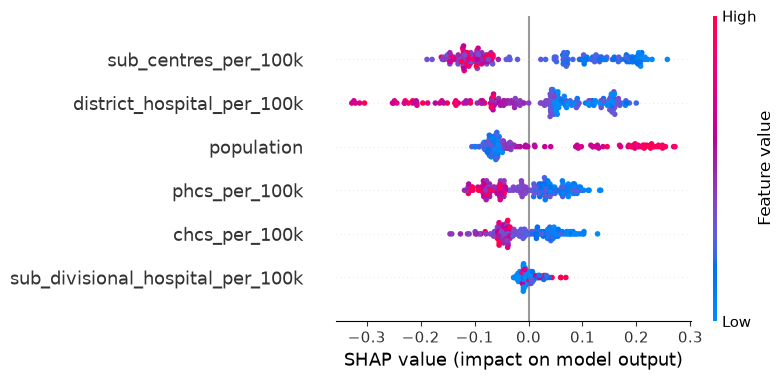

In [72]:
# Create the final SHAP summary plot for the underserved class.
# Positive SHAP values push the prediction toward class 1 (underserved).
# Negative SHAP values push the prediction away from class 1.

shap.summary_plot(
    shap_values_final_class1,
    X_test_final,
    feature_names=feature_columns
)

“The SHAP analysis identified sub-centres per 100,000 population and district hospitals per 100,000 population as the most influential features in the Random Forest predictions. Lower values of these facility-density measures frequently contributed toward predictions of the underserved class.”


In [73]:
# Create a copy of the test data for error analysis.
error_analysis_df = test_df_final.copy()

# Store the actual target values.
error_analysis_df["actual"] = y_test_final.values

# Store the Random Forest predictions.
error_analysis_df["predicted"] = tuned_rf_pred

# Store the predicted probability of the underserved class.
error_analysis_df["probability_underserved"] = tuned_rf_prob

# Identify false positives.
# These districts were predicted as underserved but were actually class 0.
error_analysis_df["error_type"] = "Correct"

error_analysis_df.loc[
    (error_analysis_df["actual"] == 0) &
    (error_analysis_df["predicted"] == 1),
    "error_type"
] = "False Positive"

# Identify false negatives.
# These districts were predicted as class 0 but were actually underserved.
error_analysis_df.loc[
    (error_analysis_df["actual"] == 1) &
    (error_analysis_df["predicted"] == 0),
    "error_type"
] = "False Negative"

# Display only the incorrectly classified observations.
errors_only = error_analysis_df[
    error_analysis_df["error_type"] != "Correct"
].copy()

# Select useful columns for interpretation.
error_columns = [
    "state",
    "district",
    "year",
    "actual",
    "predicted",
    "probability_underserved",
    "error_type"
]

# Display the errors.
errors_only[error_columns]

,state,district,year,actual,predicted,probability_underserved,error_type
34,Rajasthan,Jaipur,2020-21,0.0,1.0,0.725431,False Positive
112,Uttar Pradesh,Rampur,2020-21,1.0,0.0,0.494903,False Negative
283,Uttar Pradesh,Ballia,2020-21,0.0,1.0,0.509894,False Positive
322,Maharashtra,Buldhana,2020-21,1.0,0.0,0.214320,False Negative
416,Karnataka,Belagavi,2020-21,1.0,0.0,0.248246,False Negative
428,Karnataka,Raichur,2020-21,1.0,0.0,0.289680,False Negative


In [74]:
# Add the six model features to the error-analysis table.
# This allows us to inspect the characteristics of the misclassified districts.

error_feature_df = errors_only[
    [
        "state",
        "district",
        "year",
        "actual",
        "predicted",
        "probability_underserved",
        "error_type"
    ]
].copy()

# Add the original feature values from the test dataset.
for feature in feature_columns:
    error_feature_df[feature] = X_test_final.loc[
        errors_only.index, feature
    ].values

# Display the error cases with their feature values.
error_feature_df

,state,district,year,actual,predicted,probability_underserved,error_type,sub_centres_per_100k,phcs_per_100k,chcs_per_100k,sub_divisional_hospital_per_100k,district_hospital_per_100k,population
34,Rajasthan,Jaipur,2020-21,0.0,1.0,0.725431,False Positive,9.371918,2.731590,0.558391,0.015092,0.015092,6626178.0
112,Uttar Pradesh,Rampur,2020-21,1.0,0.0,0.494903,False Negative,9.033234,1.498404,0.214058,0.000000,0.085623,2335819.0
283,Uttar Pradesh,Ballia,2020-21,0.0,1.0,0.509894,False Positive,11.327951,2.500174,0.277797,0.000000,0.061733,3239774.0
322,Maharashtra,Buldhana,2020-21,1.0,0.0,0.214320,False Negative,10.826453,2.242622,0.463991,0.038666,0.077332,2586258.0
416,Karnataka,Belagavi,2020-21,1.0,0.0,0.248246,False Negative,12.992553,3.201064,0.334752,0.188298,0.020922,4779661.0
428,Karnataka,Raichur,2020-21,1.0,0.0,0.289680,False Negative,11.043067,2.955187,0.311072,0.207382,0.051845,1928812.0


In [75]:
# Define the five healthcare facility-density features without population.
facility_only_features = [
    "sub_centres_per_100k",
    "phcs_per_100k",
    "chcs_per_100k",
    "sub_divisional_hospital_per_100k",
    "district_hospital_per_100k"
]

# Create training and test datasets using only healthcare facility features.
X_train_facility = X_train_final[facility_only_features].copy()
X_test_facility = X_test_final[facility_only_features].copy()

# Create a Random Forest with the same tuned parameters.
rf_facility_only = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_split=5,
    random_state=42
)

# Train the facility-only model.
rf_facility_only.fit(
    X_train_facility,
    y_train_final
)

# Generate predictions for the facility-only model.
facility_pred = rf_facility_only.predict(X_test_facility)

# Generate probability estimates for the underserved class.
facility_prob = rf_facility_only.predict_proba(
    X_test_facility
)[:, 1]

# Calculate the evaluation metrics.
facility_metrics = calculate_metrics(
    y_test_final,
    facility_pred,
    facility_prob
)

# Display the facility-only results.
print("Facility-only Random Forest:")

for metric, value in facility_metrics.items():
    # Print each metric rounded to four decimal places.
    print(f"{metric}: {value:.4f}")

# Display the corresponding full-feature model results.
print("\nFull-feature Random Forest:")
for metric, value in tuned_rf_metrics.items():
    # Print each metric rounded to four decimal places.
    print(f"{metric}: {value:.4f}")

Facility-only Random Forest:
Accuracy: 0.9552
Precision: 0.8983
Recall: 0.9464
F1: 0.9217
ROC-AUC: 0.9883
PR-AUC: 0.9807

Full-feature Random Forest:
Accuracy: 0.9701
Precision: 0.9630
Recall: 0.9286
F1: 0.9455
ROC-AUC: 0.9932
PR-AUC: 0.9852


“Adding population to the facility-density features improved overall discrimination and precision, increasing F1 from 0.9217 to 0.9455 and ROC-AUC from 0.9883 to 0.9932. However, the facility-only model achieved slightly higher recall, indicating a trade-off between identifying more underserved districts and reducing false positive predictions.”

In [76]:
# Create a clean table containing the final model comparison.
final_model_table = final_results_df.copy()

# Add the tuned Random Forest results explicitly.
final_model_table.loc["Tuned Random Forest"] = tuned_rf_metrics

# Add the facility-only Random Forest experiment.
final_model_table.loc["Facility-only Random Forest"] = facility_metrics

# Round all metrics to four decimal places.
final_model_table = final_model_table.round(4)

# Display the complete results table.
final_model_table

,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC
Logistic Regression,0.9403,0.8929,0.8929,0.8929,0.9814,0.9577
Decision Tree,0.9005,0.8333,0.8036,0.8182,0.9622,0.9033
Random Forest,0.9751,0.9636,0.9464,0.9550,0.9932,0.9846
Tuned Random Forest,0.9701,0.9630,0.9286,0.9455,0.9932,0.9852
Facility-only Random Forest,0.9552,0.8983,0.9464,0.9217,0.9883,0.9807


<Figure size 1000x600 with 0 Axes>

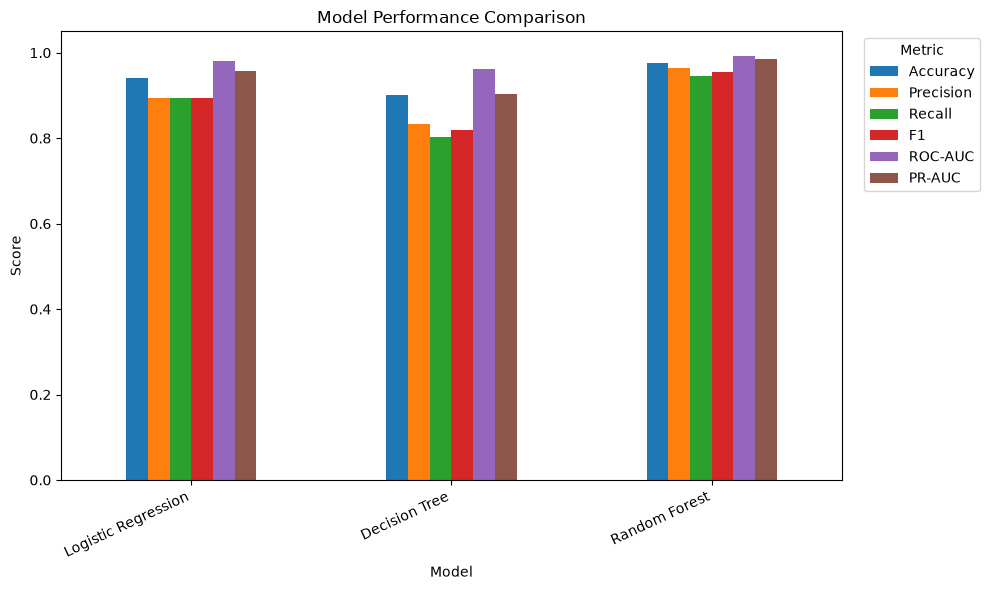

In [77]:
# Import matplotlib for creating the model comparison figure.
import matplotlib.pyplot as plt

# Create a figure for the model comparison.
plt.figure(figsize=(10, 6))

# Plot the six evaluation metrics for each model.
final_results_df.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add a descriptive title.
plt.title("Model Performance Comparison")

# Label the x-axis.
plt.xlabel("Model")

# Label the y-axis.
plt.ylabel("Score")

# Rotate model names so they are easier to read.
plt.xticks(rotation=25, ha="right")

# Keep the score range between 0 and 1.
plt.ylim(0, 1.05)

# Add a legend for the evaluation metrics.
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

# Adjust the layout so labels do not get cut off.
plt.tight_layout()

# Display the figure.
plt.show()

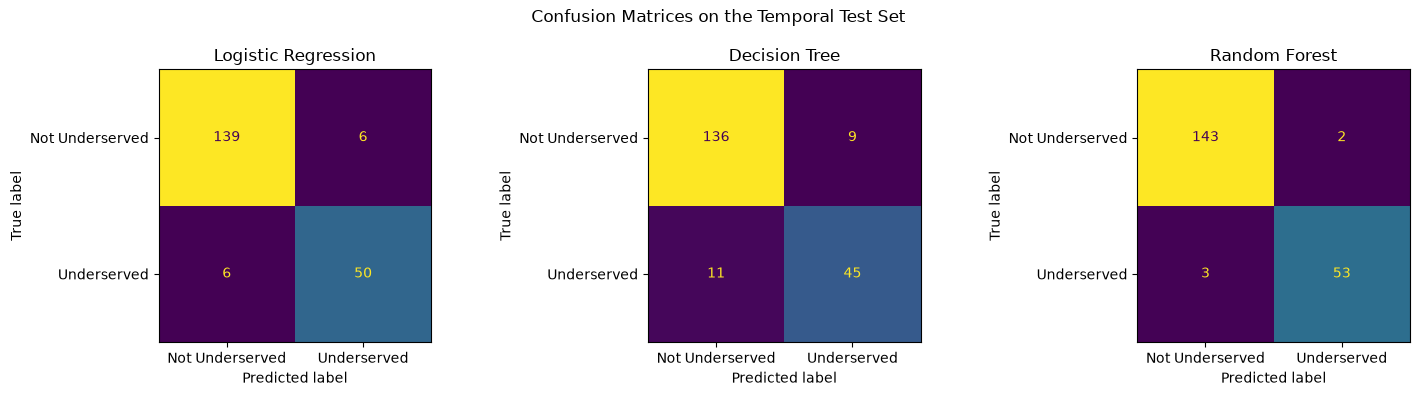

In [78]:
# Import matplotlib and the confusion matrix display utility.
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create a figure with three side-by-side confusion matrices.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Display the Logistic Regression confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False
)
axes[0].set_title("Logistic Regression")

# Display the Decision Tree confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False
)
axes[1].set_title("Decision Tree")

# Display the Random Forest confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[2],
    values_format="d",
    colorbar=False
)
axes[2].set_title("Random Forest")

# Add an overall title.
fig.suptitle("Confusion Matrices on the Temporal Test Set")

# Adjust spacing between the plots.
plt.tight_layout()

# Display the figure.
plt.show()

In [79]:
# Create a folder for the final project results.
import os

os.makedirs("results", exist_ok=True)

# Save the main model comparison results.
final_results_df.to_csv(
    "results/model_comparison.csv"
)

# Save the complete experiment comparison.
final_model_table.to_csv(
    "results/final_model_results.csv"
)

# Save the final permutation importance results.
permutation_final_df.to_csv(
    "results/permutation_importance.csv",
    index=False
)

# Save the six model error cases.
error_feature_df.to_csv(
    "results/error_analysis.csv",
    index=False
)

# Save the facility-only feature experiment.
facility_results_df = pd.DataFrame(
    [facility_metrics],
    index=["Facility-only Random Forest"]
)

facility_results_df.to_csv(
    "results/facility_only_results.csv"
)

# Confirm that the result files were saved.
print("Final result files saved successfully.")

Final result files saved successfully.


In [80]:
# Create a folder for the final figures.
import os
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

os.makedirs("results/figures", exist_ok=True)

# -----------------------------
# Save model comparison figure
# -----------------------------

# Create the model comparison plot.
ax = final_results_df.plot(
    kind="bar",
    figsize=(10, 6)
)

# Add plot labels and formatting.
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.legend(
    title="Metric",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()

# Save the figure as a PNG file.
plt.savefig(
    "results/figures/model_performance_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

# Close the figure to avoid overlapping plots.
plt.close()


# -----------------------------
# Save confusion matrix figure
# -----------------------------

# Create three side-by-side confusion matrices.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[0],
    values_format="d",
    colorbar=False
)
axes[0].set_title("Logistic Regression")

# Decision Tree confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=tree_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[1],
    values_format="d",
    colorbar=False
)
axes[1].set_title("Decision Tree")

# Random Forest confusion matrix.
ConfusionMatrixDisplay(
    confusion_matrix=rf_cm,
    display_labels=["Not Underserved", "Underserved"]
).plot(
    ax=axes[2],
    values_format="d",
    colorbar=False
)
axes[2].set_title("Random Forest")

# Add the overall figure title.
fig.suptitle("Confusion Matrices on the Temporal Test Set")

# Adjust the layout.
plt.tight_layout()

# Save the confusion matrix figure.
plt.savefig(
    "results/figures/confusion_matrices.png",
    dpi=300,
    bbox_inches="tight"
)

# Close the figure.
plt.close()

# Confirm that the figures were saved.
print("Final figures saved successfully.")

Final figures saved successfully.


In [81]:
# Create the permutation-importance figure.
import matplotlib.pyplot as plt

# Sort the final permutation importance values for plotting.
plot_permutation = permutation_final_df.sort_values(
    "importance_mean",
    ascending=True
)

# Create a horizontal bar chart.
plt.figure(figsize=(9, 5))

plt.barh(
    plot_permutation["feature"],
    plot_permutation["importance_mean"]
)

# Add labels and title.
plt.xlabel("Mean permutation importance")
plt.ylabel("Feature")
plt.title("Permutation Feature Importance")

# Adjust the layout.
plt.tight_layout()

# Save the permutation importance figure.
plt.savefig(
    "results/figures/permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

# Close the figure.
plt.close()


# -----------------------------
# Save the SHAP summary figure
# -----------------------------

# Create the final SHAP summary plot.
shap.summary_plot(
    shap_values_final_class1,
    X_test_final,
    feature_names=feature_columns,
    show=False
)

# Add a title.
plt.title("SHAP Summary for Underserved Prediction")

# Adjust the layout.
plt.tight_layout()

# Save the SHAP figure.
plt.savefig(
    "results/figures/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

# Close the figure.
plt.close()

# Confirm that both explainability figures were saved.
print("Explainability figures saved successfully.")

Explainability figures saved successfully.


## Research Questions and Findings

### RQ1: Can historical healthcare facility availability and population pressure predict future underserved status?

Yes, the temporal experiment shows that facility-density features and population can be used to predict the next year's underserved label in the pilot dataset. The tuned Random Forest achieved an F1-score of 0.9455, ROC-AUC of 0.9932, and PR-AUC of 0.9852 on the held-out 2020-21 to 2021-22 temporal test transition.

These results should be interpreted as performance on this specific pilot dataset and temporal test period, rather than as evidence of nationwide generalization.

### RQ2: Does adding population provide additional predictive information beyond facility-density features?

Adding population improved several overall performance measures. The full-feature Random Forest achieved an F1-score of 0.9455 compared with 0.9217 for the facility-only model. ROC-AUC increased from 0.9883 to 0.9932, while PR-AUC increased from 0.9807 to 0.9852.

The facility-only model had slightly higher recall (0.9464 compared with 0.9286), showing a trade-off between recall and the other performance measures.

### RQ3: Which features contribute most to the Random Forest predictions?

Permutation importance identified sub-centres per 100,000 population and district hospitals per 100,000 population as the two most influential features. SHAP analysis produced a similar overall ordering, with these two features having the largest influence on the model predictions.

Lower values of several facility-density measures frequently contributed toward predictions of the underserved class. These explanations describe model behavior and should not be interpreted as causal effects.

### RQ4: Does hyperparameter tuning improve Random Forest performance?

Hyperparameter optimization selected 200 estimators, a maximum depth of 5, and a minimum samples split of 5. The best cross-validation F1-score was 0.8289.

On the held-out temporal test set, the tuned Random Forest achieved an F1-score of 0.9455 compared with 0.9550 for the original Random Forest. PR-AUC increased slightly from 0.9846 to 0.9852, while accuracy, recall, and F1 decreased slightly.

Therefore, tuning did not improve every test metric, but it provided a useful controlled experiment on the effect of model complexity.

### RQ5: What types of prediction errors remain?

The tuned Random Forest produced 2 false positives and 4 false negatives on the 201 district-year test observations. Jaipur and Ballia were false positives, while Rampur, Buldhana, Belagavi, and Raichur were false negatives.

Two of the errors were close to the 0.5 classification threshold, suggesting borderline predictions. The remaining errors indicate that facility-density and population features do not capture all district-level variation relevant to the target.

### Overall Finding

The pilot study demonstrates a reproducible temporal machine-learning workflow for identifying districts that meet the project's operational definition of underserved status in the following year. Random Forest provided strong predictive performance on the held-out temporal test period, while permutation importance and SHAP provided interpretable information about the features used by the model.

The D-HAI is an accessibility proxy based on the available pilot indicators. It does not represent complete healthcare accessibility because factors such as affordability, quality, travel time, service utilization, and other dimensions are not included in the current pilot dataset.

## Conclusion

This project developed a reproducible machine-learning workflow for assessing district-level healthcare facility availability and predicting next-year underserved status using a pilot dataset of Indian districts.

The D-HAI was constructed using five public healthcare facility-density indicators normalized per 100,000 population. A fixed temporal threshold was then used to define the operational underserved label, and a strict year-to-year prediction setup was used to avoid using future observations during model evaluation.

Three baseline models were evaluated: Logistic Regression, Decision Tree, and Random Forest. Random Forest produced the strongest performance on the held-out temporal test period, while hyperparameter tuning provided a controlled experiment on model complexity.

Permutation importance and SHAP were used to interpret the Random Forest predictions. Sub-centres per 100,000 population and district hospitals per 100,000 population were among the most influential features.

The feature-set experiment also showed that adding population improved overall F1, ROC-AUC, and PR-AUC compared with using facility-density features alone, although the facility-only model achieved slightly higher recall.

## Limitations

1. The current D-HAI is an accessibility proxy based on five facility-count indicators and population.
2. The pilot dataset does not currently include all possible dimensions of healthcare accessibility.
3. Affordability, healthcare quality, travel time, service utilization, and other accessibility dimensions are not represented.
4. Population information is based on the available population matching in the pilot data, and district boundary changes can create matching challenges.
5. The machine-learning evaluation uses a limited temporal pilot dataset covering the available matched districts and years.
6. Strong test performance on this pilot period does not guarantee nationwide or future generalization.
7. SHAP and permutation importance explain model behavior but do not establish causal relationships.
8. The underserved label is an operational definition based on the D-HAI threshold and should not be interpreted as an official healthcare policy classification.

## Future Work

Future versions can incorporate additional healthcare capacity indicators such as beds and human resources where consistent district-year data are available. Facility-location data, travel distance, utilization indicators, and more recent population estimates could also improve the accessibility proxy.

Expanding the dataset to more states and additional years would allow stronger temporal and geographic validation and provide a better assessment of model generalization.

In [82]:
# Import os to check whether important result files exist.
import os

# List the important files produced by the project.
required_files = [
    "dhai_v1_results.csv",
    "results/model_comparison.csv",
    "results/final_model_results.csv",
    "results/permutation_importance.csv",
    "results/error_analysis.csv",
    "results/facility_only_results.csv",
    "results/figures/model_performance_comparison.png",
    "results/figures/confusion_matrices.png",
    "results/figures/permutation_importance.png",
    "results/figures/shap_summary.png"
]

# Check every file and print its status.
print("FINAL FILE AUDIT")
print("-" * 40)

for file_path in required_files:
    # Check whether the file exists.
    status = "OK" if os.path.exists(file_path) else "MISSING"

    # Display the result for this file.
    print(f"{status:8} {file_path}")

# Check that the final tuned model and SHAP values are available.
print("\nFINAL MODEL CHECK")
print("-" * 40)

print("Tuned Random Forest:", type(best_rf_final).__name__)
print("Test rows:", len(X_test_final))
print("Test features:", X_test_final.shape[1])
print("SHAP values:", shap_values_final_class1.shape)

# Display the final tuned Random Forest metrics.
print("\nFINAL TUNED RANDOM FOREST")
print("-" * 40)

for metric, value in tuned_rf_metrics.items():
    # Print each final metric rounded to four decimal places.
    print(f"{metric}: {value:.4f}")

FINAL FILE AUDIT
----------------------------------------
OK       dhai_v1_results.csv
OK       results/model_comparison.csv
OK       results/final_model_results.csv
OK       results/permutation_importance.csv
OK       results/error_analysis.csv
OK       results/facility_only_results.csv
OK       results/figures/model_performance_comparison.png
OK       results/figures/confusion_matrices.png
OK       results/figures/permutation_importance.png
OK       results/figures/shap_summary.png

FINAL MODEL CHECK
----------------------------------------
Tuned Random Forest: RandomForestClassifier
Test rows: 201
Test features: 6
SHAP values: (201, 6)

FINAL TUNED RANDOM FOREST
----------------------------------------
Accuracy: 0.9701
Precision: 0.9630
Recall: 0.9286
F1: 0.9455
ROC-AUC: 0.9932
PR-AUC: 0.9852


In [83]:
# Save the exact 400-row dataset used for machine-learning experiments.
# This contains the features, target, district information, and year.

df_ml_final = df_ml.copy()

# Save the final ML dataset.
df_ml_final.to_csv(
    "results/final_ml_dataset.csv",
    index=False
)

# Create a dataframe containing the final class-1 SHAP values.
# Each row corresponds to one test observation.
shap_values_df = pd.DataFrame(
    shap_values_final_class1,
    columns=feature_columns
)

# Save the SHAP values for reproducibility.
shap_values_df.to_csv(
    "results/shap_values_class1.csv",
    index=False
)

# Confirm that both files were saved.
print("Final ML dataset and SHAP values saved successfully.")

Final ML dataset and SHAP values saved successfully.


In [84]:
# Import the main packages used in the project.
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import shap

# Display the installed package versions.
print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("scikit-learn:", sklearn.__version__)
print("matplotlib:", matplotlib.__version__)
print("shap:", shap.__version__)

pandas: 3.0.3
numpy: 2.4.6
scikit-learn: 1.9.0
matplotlib: 3.11.0
shap: 0.52.0
